In [8]:
import numpy as np
import arviz as az

# Example:
A = np.array([
    [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1]
])

y = np.array([1087, 1008, 1068, 1204, 1158, 1151, 1143]).reshape(-1, 1)

# Matrix multiplication
#result1 = A @ A.T      # 7x28 times 28x7 -> 7x7
result2 = A.T @ y      # 28x7 times 7x1 -> 28x1
#result3 = A @ (A.T @ y)  # 7x28 times 28x1 -> 7x1

#print("A @ A.T =\n", result1)
print("\nA.T @ y =\n", result2)
#print("\nA @ (A.T @ y) =\n", result3)




A.T @ y =
 [[1087]
 [2095]
 [3163]
 [4367]
 [5525]
 [6676]
 [7819]
 [1008]
 [2076]
 [3280]
 [4438]
 [5589]
 [6732]
 [1068]
 [2272]
 [3430]
 [4581]
 [5724]
 [1204]
 [2362]
 [3513]
 [4656]
 [1158]
 [2309]
 [3452]
 [1151]
 [2294]
 [1143]]


In [13]:
y

array([[1087],
       [1008],
       [1068],
       [1204],
       [1158],
       [1151],
       [1143]])

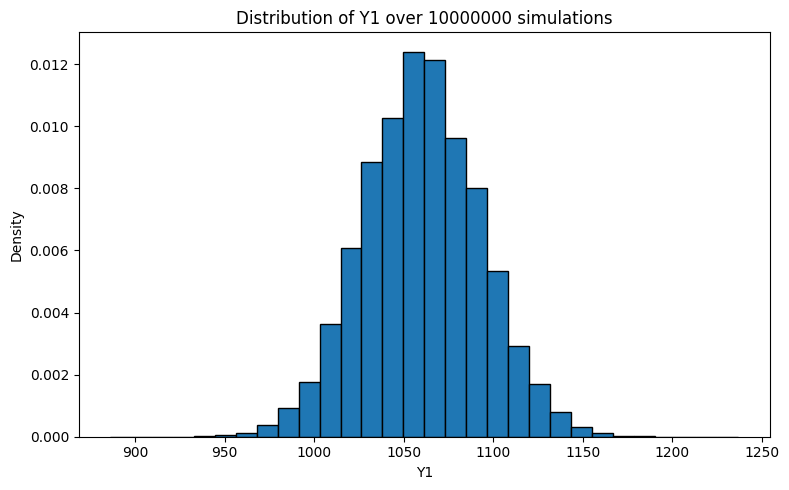

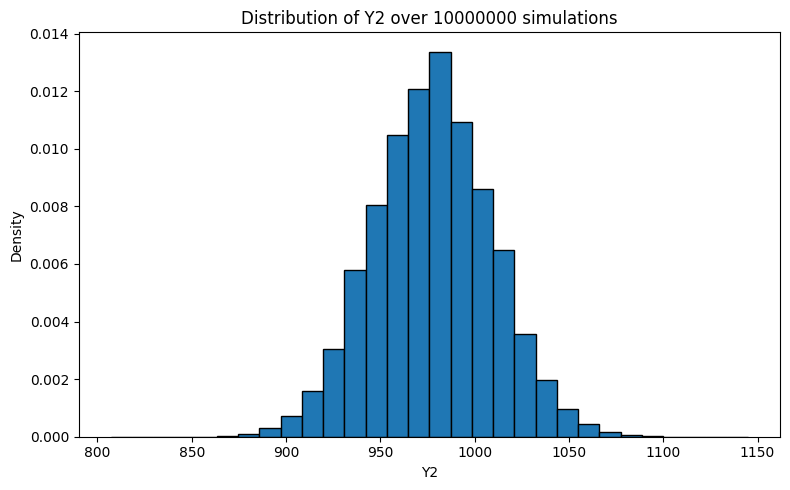

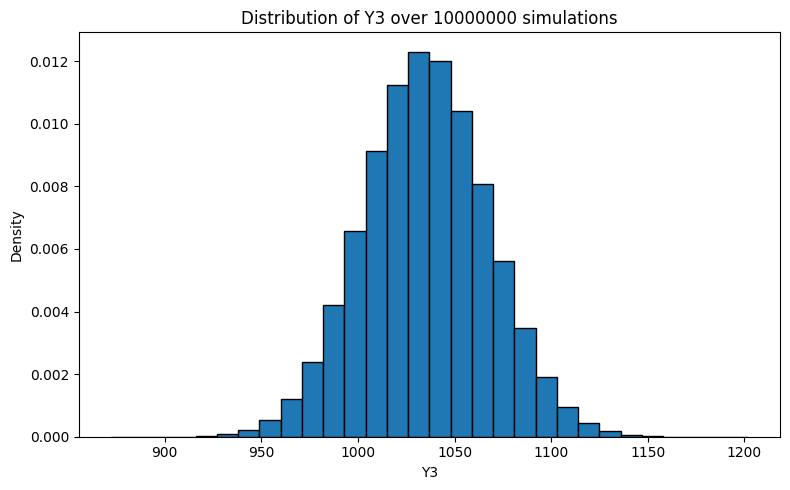

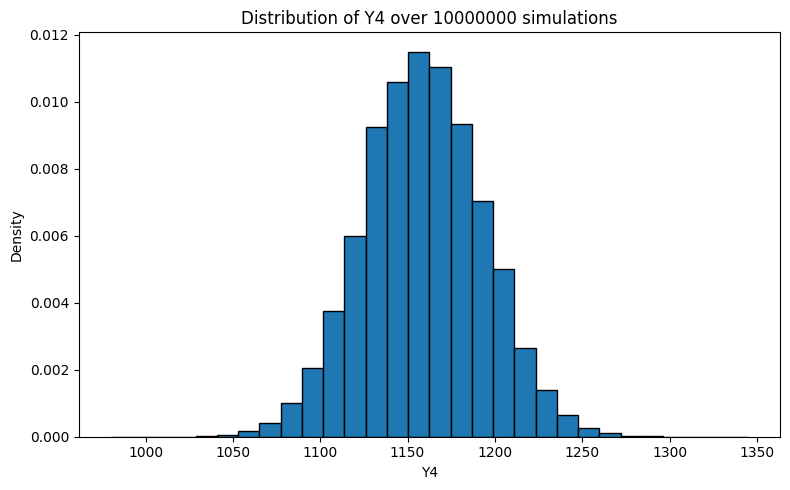

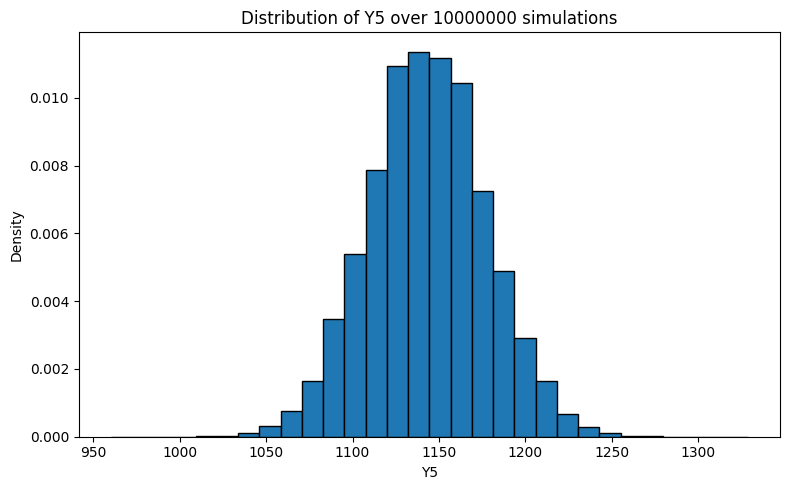

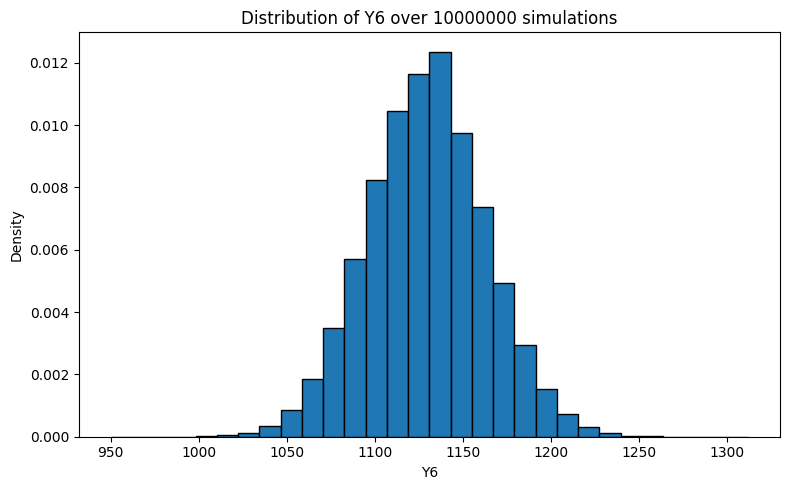

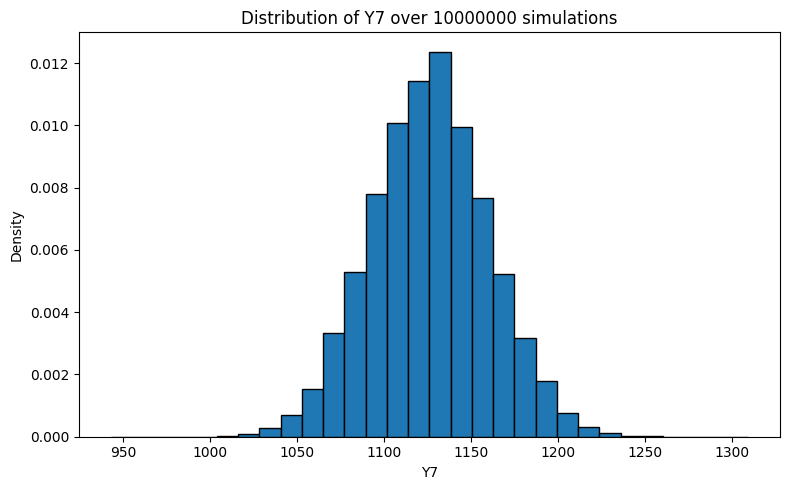

Average Y values:
Y1: 1059.99
Y2: 977.59
Y3: 1034.59
Y4: 1158.89
Y5: 1143.39
Y6: 1129.29
Y7: 1126.09


In [14]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_sim = 10000000

# 7 x 28 configuration matrix A
A = np.array([
    [1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,1,1,1,1,0,0,1,1,1,1,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0],
    [0,0,0,0,1,1,1,0,0,0,1,1,1,0,0,1,1,1,0,1,1,1,1,1,1,0,0,0],
    [0,0,0,0,0,1,1,0,0,0,0,1,1,0,0,0,1,1,0,0,1,1,0,1,1,1,1,0],
    [0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1,1]
], dtype=int)

# Poisson means for the 28 OD flows
theta = np.array([
    83.0, 25.0, 19.0, 89.0, 10.0,  9.0, 825.0,
            0.1,  0.1,  0.1,  0.1,  0.1,  0.1,
                  0.1,  5.0,  1.0,  2.0, 74.0,
                       0.5, 36.0,  2.0, 105.0,
                             10.0,  0.1, 69.0,
                                    5.0, 38.0,
                                        15.0
])

# Simulate 1000 X vectors
X_sims = np.random.poisson(lam=theta, size=(n_sim, len(theta)))

# Compute Y = AX for each simulation
Y_sims = X_sims @ A.T   # shape: (1000, 7)

# Plot distributions of Y1,...,Y7
for i in range(7):
    plt.figure(figsize=(8, 5))
    plt.hist(Y_sims[:, i], bins=30, edgecolor='black', density=True)
    plt.xlabel(f"Y{i+1}")
    plt.ylabel("Density")
    plt.title(f"Distribution of Y{i+1} over {n_sim} simulations")
    plt.tight_layout()
    plt.show()

print("Average Y values:")
for i in range(7):
    print(f"Y{i+1}: {Y_sims[:, i].mean():.2f}")

In [15]:
import numpy as np

y_obs = np.array([1087, 1008, 1068, 1204, 1158, 1151, 1143])

y_mean = Y_sims.mean(axis=0)
y_std = Y_sims.std(axis=0, ddof=1)   # sample std

z_scores = (y_obs - y_mean) / y_std

print("Means:", y_mean)
print("Standard deviations:", y_std)
print("Z-scores (number of SDs from the mean):", z_scores)

for i, z in enumerate(z_scores, start=1):
    print(f"Y{i}: {z:.2f} standard deviations from the mean")

Means: [1059.9934207  977.5903955 1034.5908852 1158.8928274 1143.3914256
 1129.2892737 1126.0906231]
Standard deviations: [32.54566419 31.25688663 32.15297466 34.02933022 33.80352335 33.59883387
 33.55142006]
Z-scores (number of SDs from the mean): [0.82980575 0.97289295 1.03906762 1.32553807 0.43216129 0.64617499
 0.50398394]
Y1: 0.83 standard deviations from the mean
Y2: 0.97 standard deviations from the mean
Y3: 1.04 standard deviations from the mean
Y4: 1.33 standard deviations from the mean
Y5: 0.43 standard deviations from the mean
Y6: 0.65 standard deviations from the mean
Y7: 0.50 standard deviations from the mean


In [36]:
#load pkl ResultsRoadsCmsgenLongrun.pkl
import pickle

with open("ResultsRoadsCmsgenLongrun.pkl", "rb") as f:
    data = pickle.load(f)
data.keys()

dict_keys([7])

In [37]:
trace=data[7][1][0][4][5000][0]


In [38]:
trace

Inference data with groups:
	> posterior

/opt/anaconda3/envs/sat_metropolis/lib/python3.12/site-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (28), generating only 20 plots
  warnings.warn(


array([[<Axes: title={'center': 'x0'}>, <Axes: title={'center': 'x0'}>],
       [<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x1'}>],
       [<Axes: title={'center': 'x2'}>, <Axes: title={'center': 'x2'}>],
       [<Axes: title={'center': 'x3'}>, <Axes: title={'center': 'x3'}>],
       [<Axes: title={'center': 'x4'}>, <Axes: title={'center': 'x4'}>],
       [<Axes: title={'center': 'x5'}>, <Axes: title={'center': 'x5'}>],
       [<Axes: title={'center': 'x6'}>, <Axes: title={'center': 'x6'}>],
       [<Axes: title={'center': 'x7'}>, <Axes: title={'center': 'x7'}>],
       [<Axes: title={'center': 'x8'}>, <Axes: title={'center': 'x8'}>],
       [<Axes: title={'center': 'x9'}>, <Axes: title={'center': 'x9'}>],
       [<Axes: title={'center': 'x10'}>, <Axes: title={'center': 'x10'}>],
       [<Axes: title={'center': 'x11'}>, <Axes: title={'center': 'x11'}>],
       [<Axes: title={'center': 'x12'}>, <Axes: title={'center': 'x12'}>],
       [<Axes: title={'center': 'x13'}>, <Axe

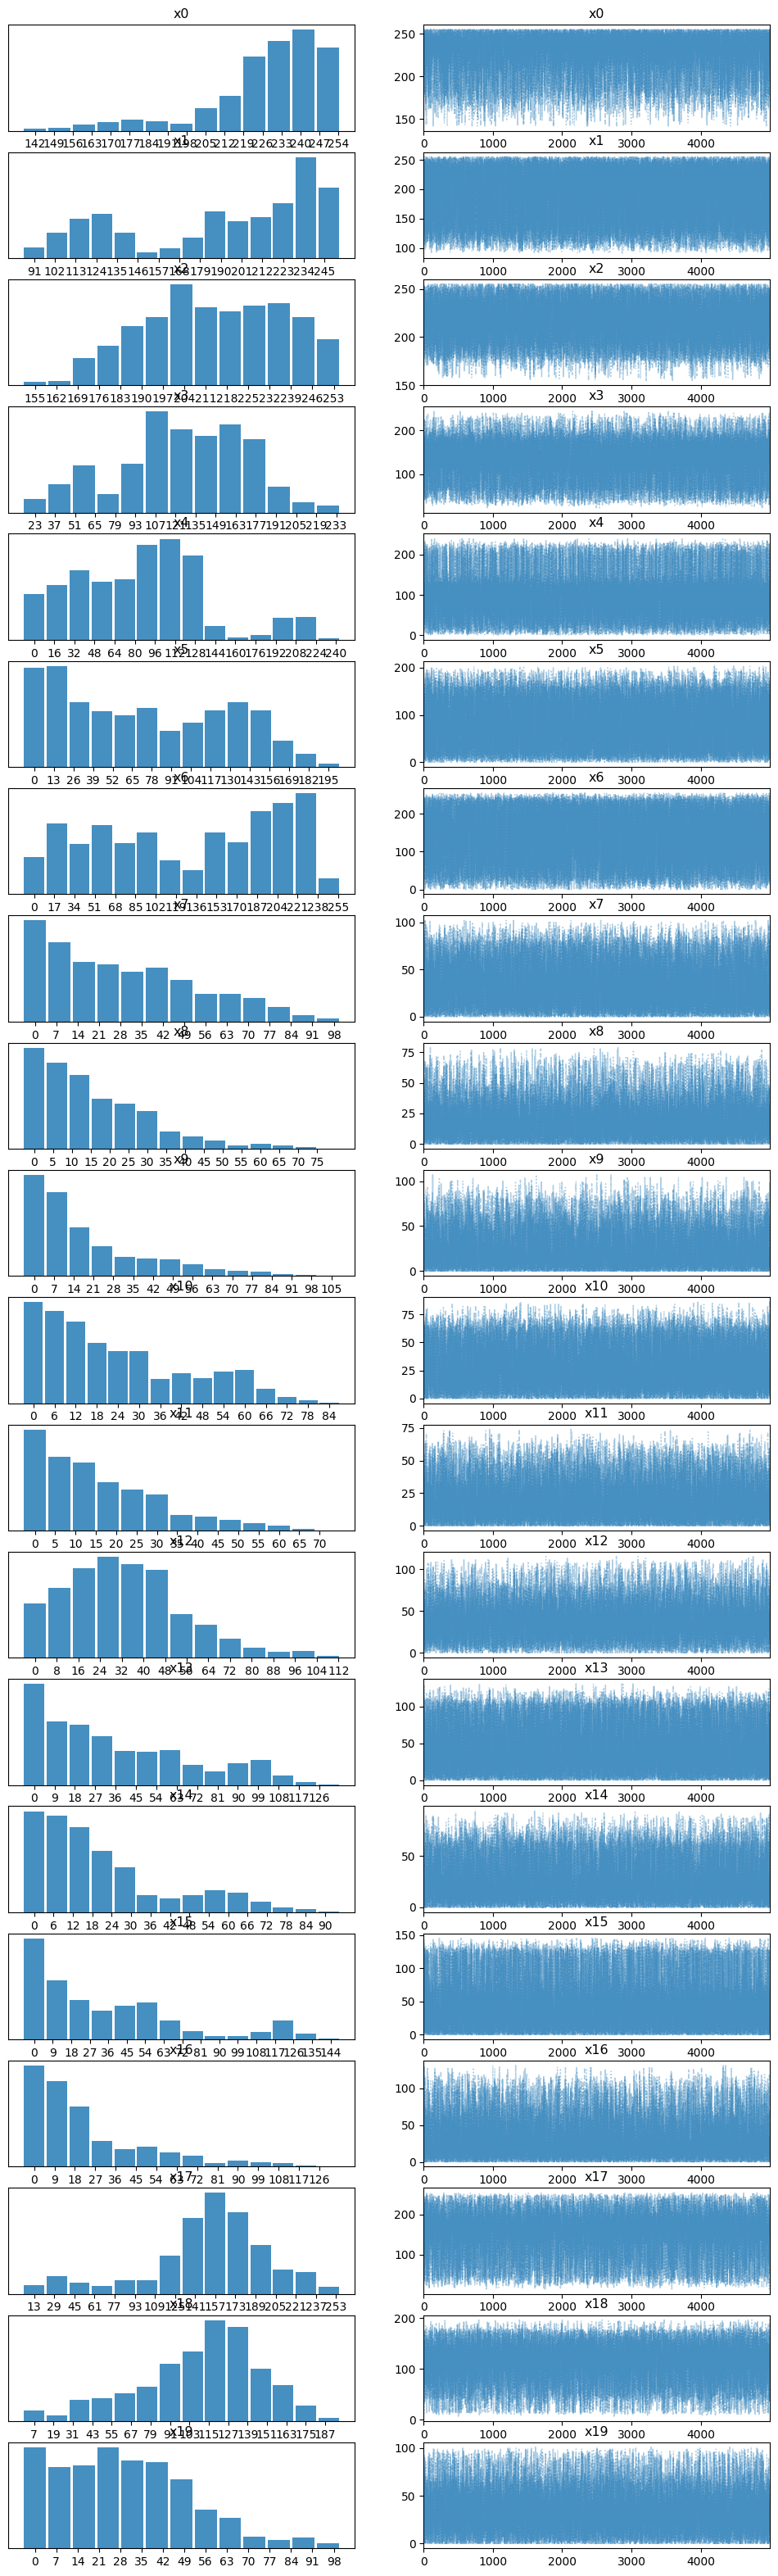

In [39]:
az.plot_trace(trace)

array([[<Axes: title={'center': 'x0'}>, <Axes: title={'center': 'x0'}>],
       [<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x1'}>],
       [<Axes: title={'center': 'x2'}>, <Axes: title={'center': 'x2'}>],
       [<Axes: title={'center': 'x3'}>, <Axes: title={'center': 'x3'}>],
       [<Axes: title={'center': 'x4'}>, <Axes: title={'center': 'x4'}>],
       [<Axes: title={'center': 'x5'}>, <Axes: title={'center': 'x5'}>],
       [<Axes: title={'center': 'x6'}>, <Axes: title={'center': 'x6'}>],
       [<Axes: title={'center': 'x7'}>, <Axes: title={'center': 'x7'}>],
       [<Axes: title={'center': 'x8'}>, <Axes: title={'center': 'x8'}>],
       [<Axes: title={'center': 'x9'}>, <Axes: title={'center': 'x9'}>],
       [<Axes: title={'center': 'x10'}>, <Axes: title={'center': 'x10'}>],
       [<Axes: title={'center': 'x11'}>, <Axes: title={'center': 'x11'}>],
       [<Axes: title={'center': 'x12'}>, <Axes: title={'center': 'x12'}>],
       [<Axes: title={'center': 'x13'}>, <Axe

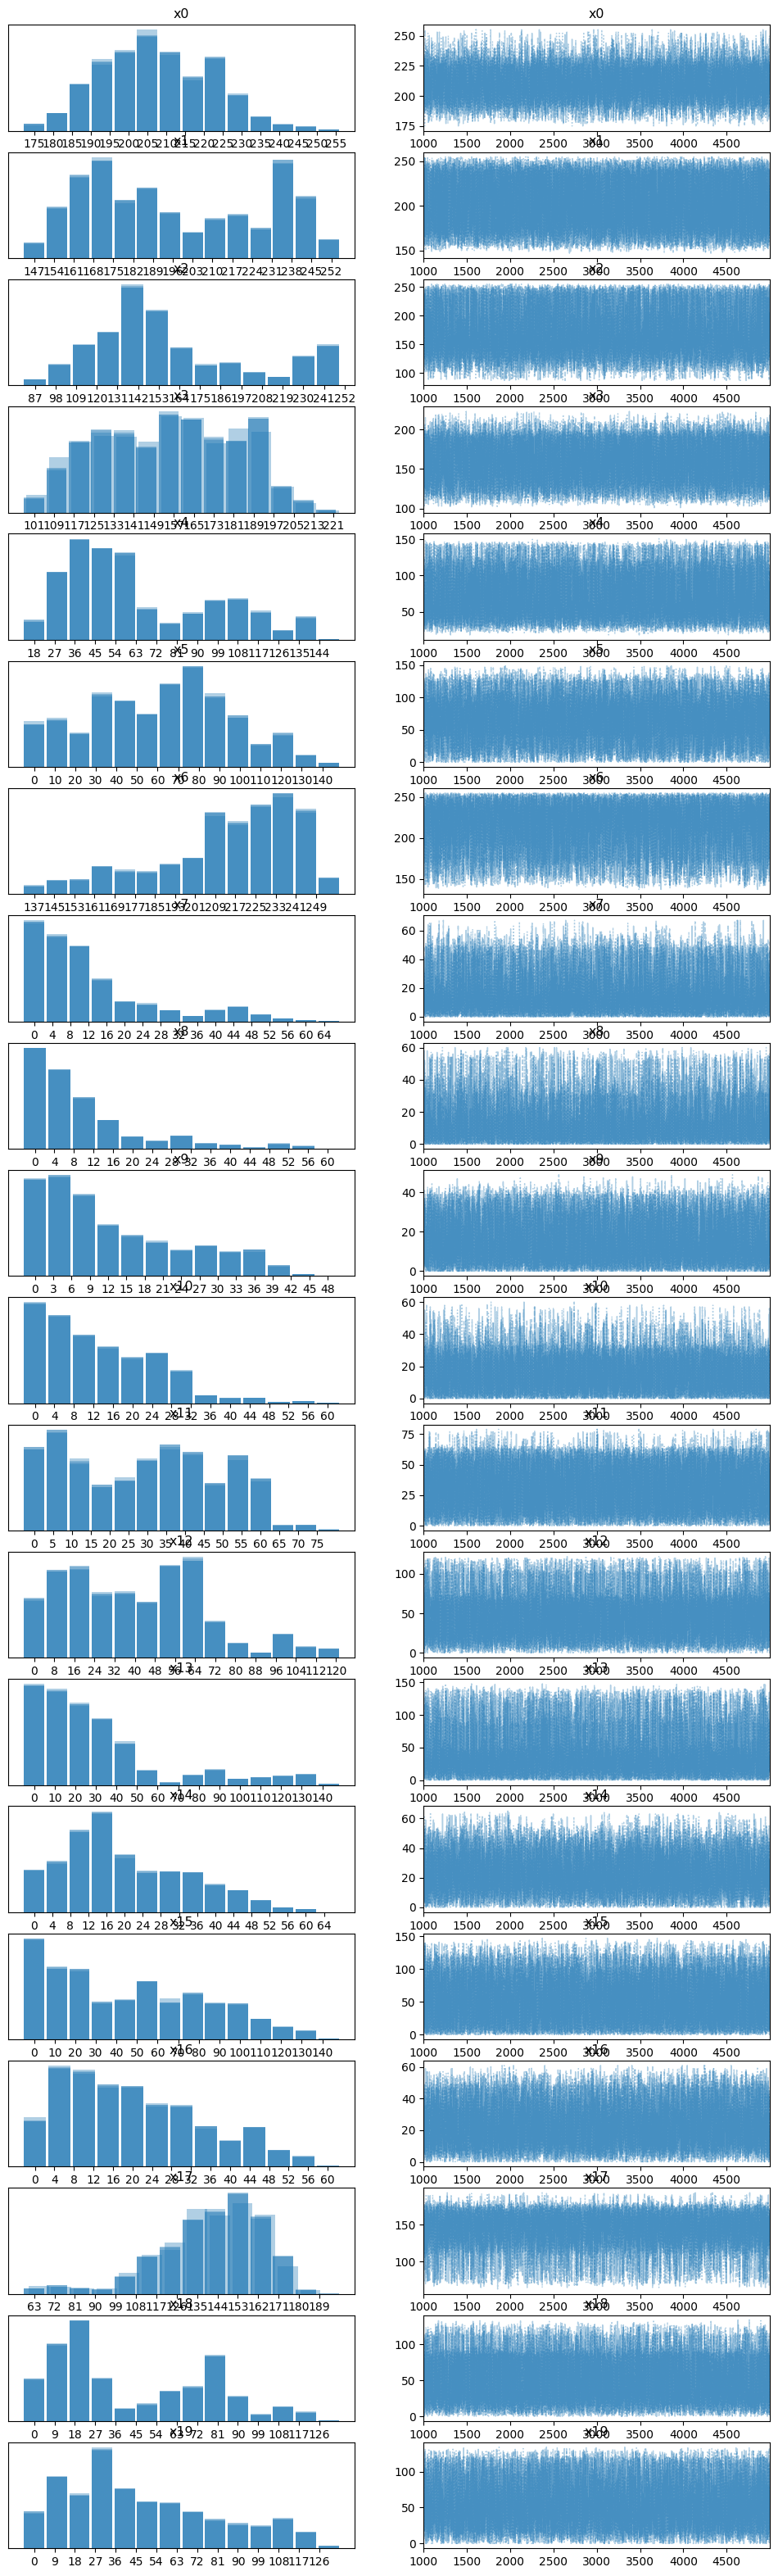

In [35]:
trimmed_trace = trace.sel(draw=slice(1000, None)).copy()
az.plot_trace(trimmed_trace)